In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

file_path = '/Users/yazevstanislav/Desktop/ПС Машинное обучение/hseml-group-project-yazevsv/data/raw/churn2.xls' 
df = pd.read_excel(file_path)

print(f"Размер датасета: {df.shape}")
display(df.head())

Размер датасета: (20000, 13)


,ID,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN,LEAVE
0,1,zero,31953,0,6,313378,161,0,4,unsat,little,no,STAY
1,2,one,36147,0,13,800586,244,0,6,unsat,little,considering,STAY
2,3,one,27273,230,0,305049,201,16,15,unsat,very_little,perhaps,STAY
3,4,zero,120070,38,33,788235,780,3,2,unsat,very_high,considering,LEAVE
4,5,one,29215,208,85,224784,241,21,1,very_unsat,little,never_thought,STAY


In [19]:
print("Типы данных в датасете:")
print(df.dtypes)
print("\nИнформация о датасете:")
df.info()

Типы данных в датасете:
ID                             int64
COLLEGE                          str
INCOME                         int64
OVERAGE                        int64
LEFTOVER                       int64
HOUSE                          int64
HANDSET_PRICE                  int64
OVER_15MINS_CALLS_PER_MONTH    int64
AVERAGE_CALL_DURATION          int64
REPORTED_SATISFACTION            str
REPORTED_USAGE_LEVEL             str
CONSIDERING_CHANGE_OF_PLAN       str
LEAVE                            str
dtype: object

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   ID                           20000 non-null  int64
 1   COLLEGE                      20000 non-null  str  
 2   INCOME                       20000 non-null  int64
 3   OVERAGE                      20000 non-null  int64
 4   LEFTOVER          

In [20]:
# Удаляем ID
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# Обрабатываем целевую переменную (LEAVE -> 1, STAY -> 0)
df['LEAVE'] = df['LEAVE'].astype(str).str.strip().map({'LEAVE': 1, 'STAY': 0})

# Проверка пропусков и их заполнение если они есть
missing_counts = df.isna().sum()
if missing_counts.sum() > 0:
    print("Найдены пропуски. Заполняем числовые медианой, категориальные модой.")
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)
else:
    print("Пропусков не обнаружено.")

# 4. Удаление дубликатов если они есть 
duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Удалено дубликатов: {duplicates}")

print(f"Размер после очистки: {df.shape}")

Пропусков не обнаружено.
Размер после очистки: (20000, 12)


In [21]:
# 1. Отношение дохода к стоимости недвижимости
# Добавляем 1 к знаменателю, чтобы избежать деления на ноль, если HOUSE == 0
df['Income_per_House'] = df['INCOME'] / (df['HOUSE'] + 1)

# 2. Флаг наличия перерасхода
df['Has_Overage'] = (df['OVERAGE'] > 0).astype(int)

# 3. Приблизительное время, затраченное на долгие звонки
df['Total_Long_Calls_Duration'] = df['OVER_15MINS_CALLS_PER_MONTH'] * df['AVERAGE_CALL_DURATION']

display(df[['Income_per_House', 'Has_Overage', 'Total_Long_Calls_Duration']].head())

,Income_per_House,Has_Overage,Total_Long_Calls_Duration
0,0.101963,0,0
1,0.045151,0,0
2,0.089405,1,240
3,0.152327,1,6
4,0.129969,1,21


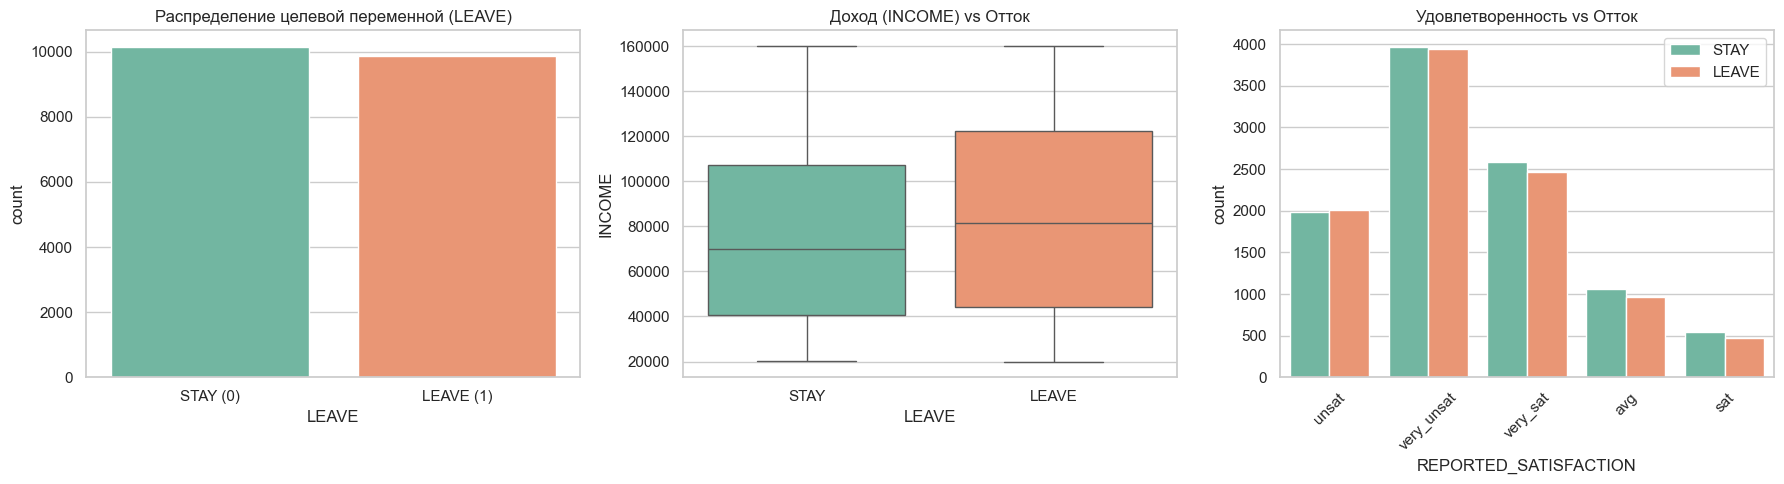

In [22]:
plt.figure(figsize=(18, 5))

# График 1: Баланс классов
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='LEAVE', palette='Set2')
plt.title('Распределение целевой переменной (LEAVE)')
plt.xticks(ticks=[0, 1], labels=['STAY (0)', 'LEAVE (1)'])

# График 2: Доход клиента vs Отток
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='LEAVE', y='INCOME', palette='Set2')
plt.title('Доход (INCOME) vs Отток')
plt.xticks(ticks=[0, 1], labels=['STAY', 'LEAVE'])

# График 3: Удовлетворенность vs Отток
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='REPORTED_SATISFACTION', hue='LEAVE', palette='Set2')
plt.title('Удовлетворенность vs Отток')
plt.legend(['STAY', 'LEAVE'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
X = df.drop('LEAVE', axis=1)
y = df['LEAVE']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train size: {X_train.shape[0]} строк")
print(f"Val size:   {X_val.shape[0]} строк")
print(f"Test size:  {X_test.shape[0]} строк")

Train size: 14000 строк
Val size:   3000 строк
Test size:  3000 строк


In [24]:
# Определяем списки категориальных и числовых колонок
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

# Пайплайн обработки
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# Обучаем только на train
X_train_processed = preprocessor.fit_transform(X_train)

# Применяем transform к val и test
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_feature_names)

X_train_final = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_val_final = pd.DataFrame(X_val_processed, columns=all_feature_names, index=X_val.index)
X_test_final = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print(f"Итоговое количество признаков: {X_train_final.shape[1]}")
display(X_train_final.head(3))

Итоговое количество признаков: 23


,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,Income_per_House,Has_Overage,Total_Long_Calls_Duration,...,REPORTED_SATISFACTION_very_sat,REPORTED_SATISFACTION_very_unsat,REPORTED_USAGE_LEVEL_high,REPORTED_USAGE_LEVEL_little,REPORTED_USAGE_LEVEL_very_high,REPORTED_USAGE_LEVEL_very_little,CONSIDERING_CHANGE_OF_PLAN_considering,CONSIDERING_CHANGE_OF_PLAN_never_thought,CONSIDERING_CHANGE_OF_PLAN_no,CONSIDERING_CHANGE_OF_PLAN_perhaps
8790,-0.421476,-1.004094,1.551060,-1.000710,1.505815,-0.898262,-0.910793,0.227027,-1.399046,-0.641817,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
13576,-0.715094,-0.401701,-0.887255,-0.765931,-1.023645,-0.450071,1.360470,-0.286858,0.714773,-0.005591,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
15026,1.190872,-1.004094,-0.324566,-0.579657,0.507098,-0.786214,-0.002287,0.856696,-1.399046,-0.562289,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [25]:
data_dir = os.path.join(os.getcwd(), '..', 'data', 'processed')
os.makedirs(data_dir, exist_ok=True)

train_data = pd.concat([X_train_final, y_train], axis=1)
val_data = pd.concat([X_val_final, y_val], axis=1)
test_data = pd.concat([X_test_final, y_test], axis=1)

train_data.to_csv(os.path.join(data_dir, 'train.csv'), index=False)
val_data.to_csv(os.path.join(data_dir, 'val.csv'), index=False)
test_data.to_csv(os.path.join(data_dir, 'test.csv'), index=False)

print("Очищенные файлы сохранены в data/processed/")

Очищенные файлы сохранены в data/processed/


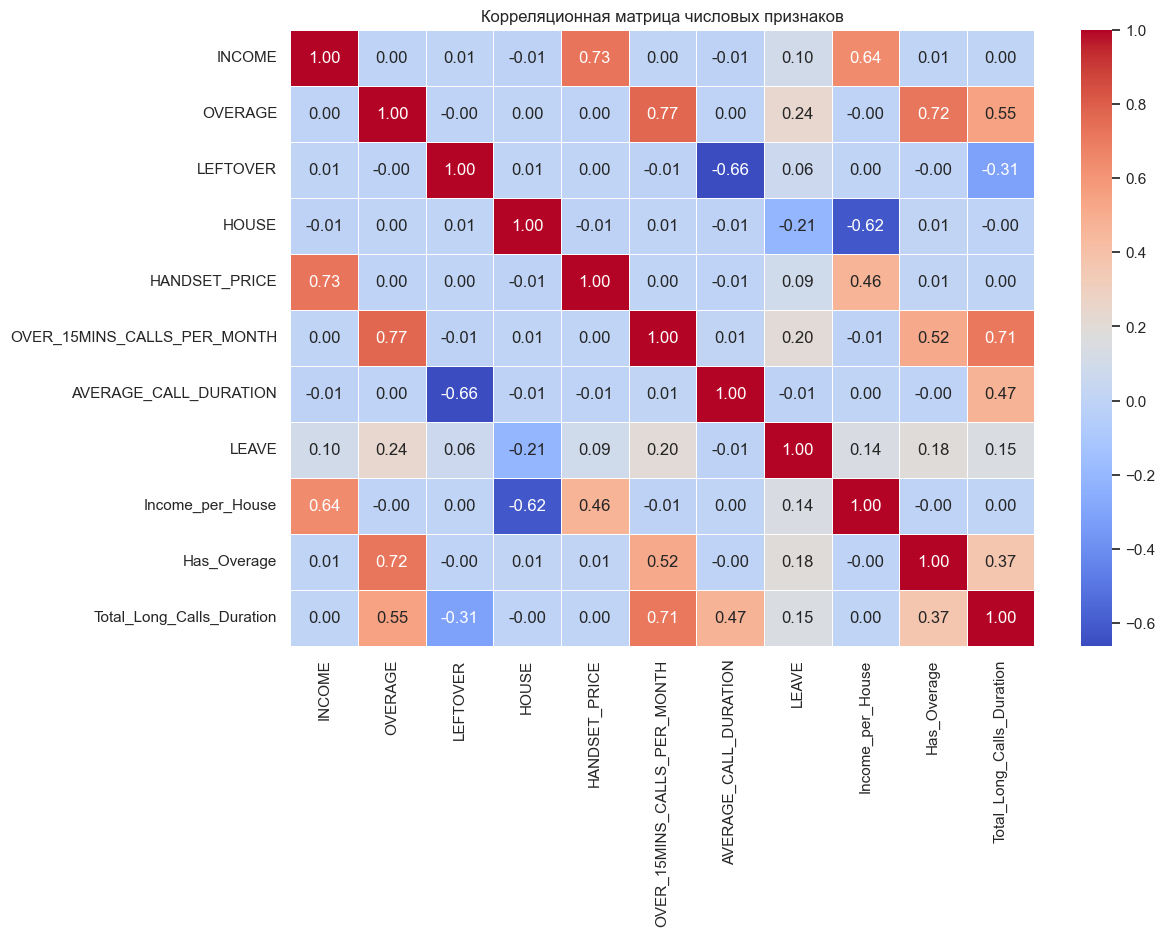

In [26]:
# Корреляционная матрица для числовых признаков
numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

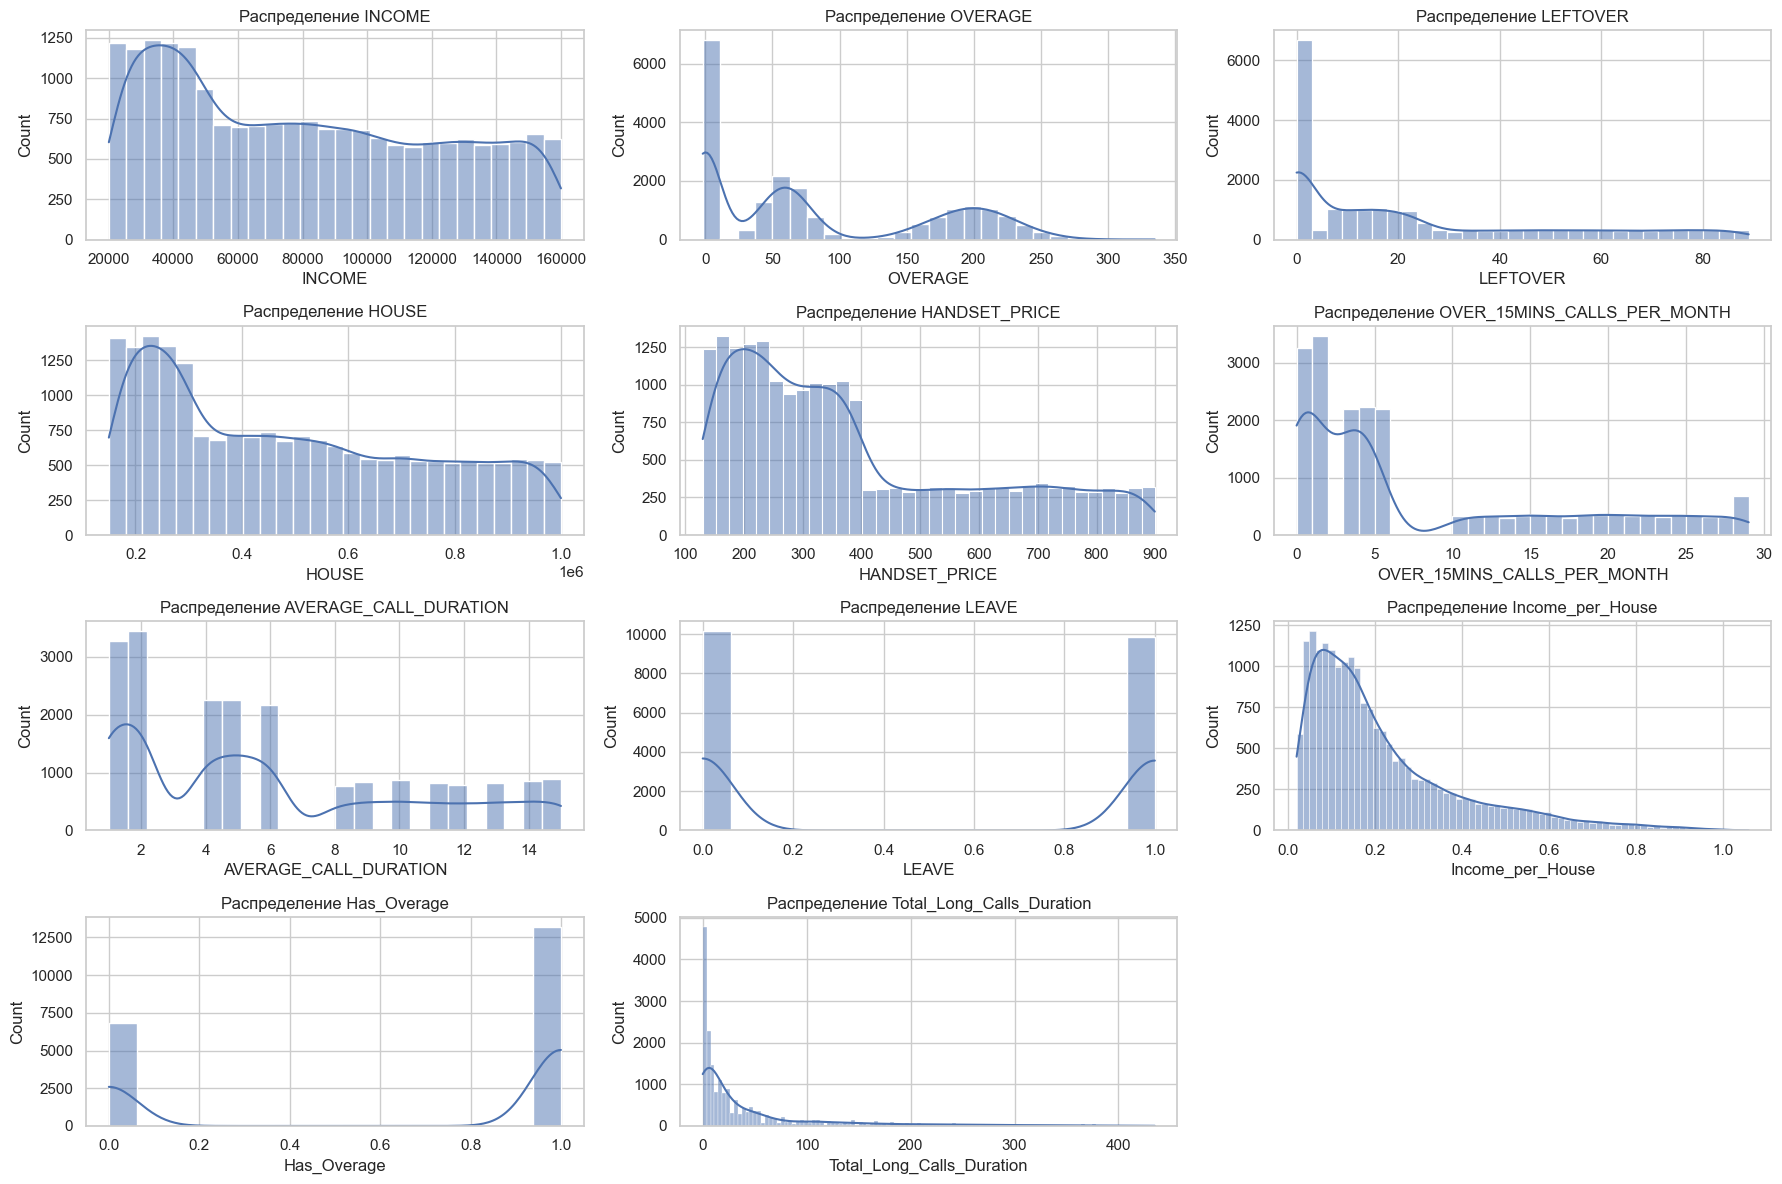

In [27]:
# Распределения числовых признаков
numerical_cols_all = df.select_dtypes(exclude=['object']).columns
fig, axes = plt.subplots(nrows=len(numerical_cols_all)//3 + 1, ncols=3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols_all):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

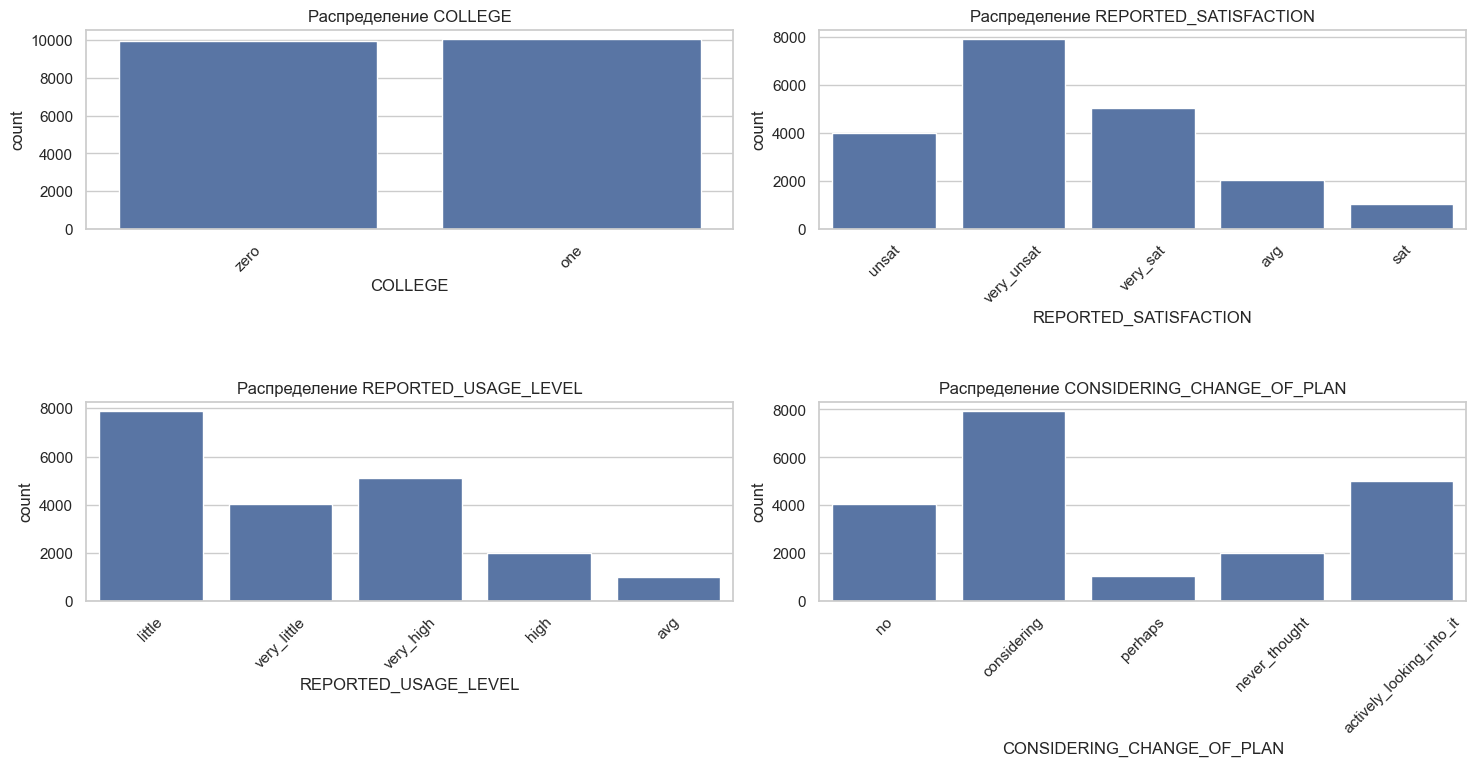

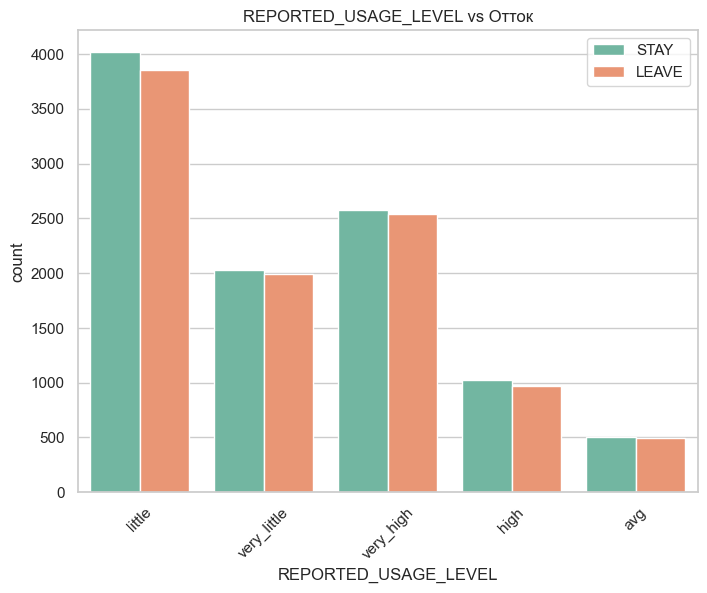

In [28]:
# Анализ категориальных признаков
categorical_cols_all = df.select_dtypes(include=['object']).columns
fig, axes = plt.subplots(nrows=len(categorical_cols_all)//2 + 1, ncols=2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols_all):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# Отдельно для REPORTED_USAGE_LEVEL vs LEAVE
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='REPORTED_USAGE_LEVEL', hue='LEAVE', palette='Set2')
plt.title('REPORTED_USAGE_LEVEL vs Отток')
plt.legend(['STAY', 'LEAVE'])
plt.xticks(rotation=45)
plt.show()

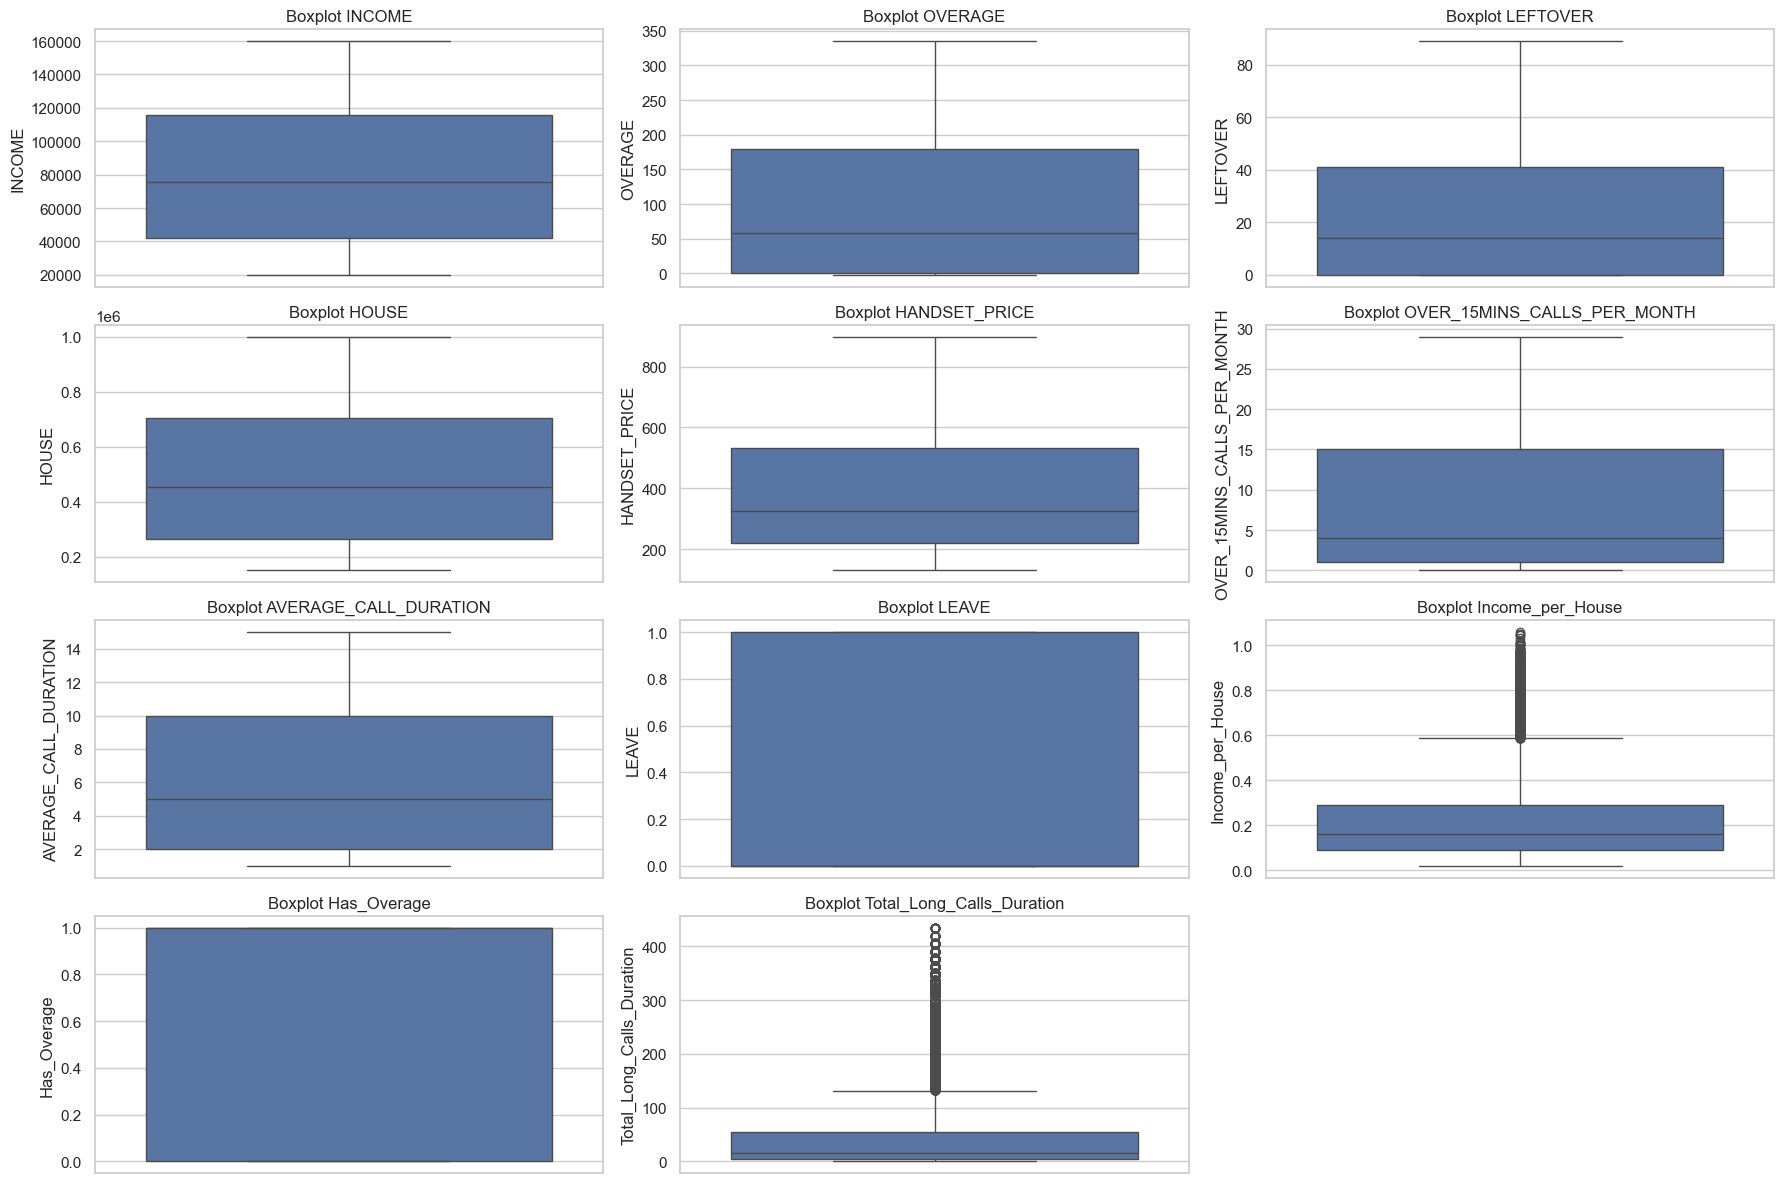

In [29]:
# Анализ выбросов для числовых признаков
fig, axes = plt.subplots(nrows=len(numerical_cols_all)//3 + 1, ncols=3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols_all):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()